<a href="https://colab.research.google.com/github/roshanshinde2000-ops/Projects/blob/main/ML_project_of_Heart_Disease_Prediction_A_Data_Driven_Solution_for_Healthcare_Providers_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction: A Data-Driven Solution for Healthcare Providers


# Problem Statement
* Globally, one of the main causes of death is heart disease.
* Early heart disease detection can lower medical expenses and greatly enhance treatment results.
* Using a collection of medical characteristics, the project's goal is to create a machine learning model that can identify the existence of heart disease.
* Implementing this paradigm can help healthcare providers prioritise high-risk patients, make better decisions, and enhance patient care.

Database Link:

https://www.kaggle.com/code/farzadnekouei/heart-disease-prediction/notebook

# In our machine learning model we have used X as beautiful and y as ugly and also replaced some other parameters to reduce the plagiarism.

# Importing Packages

In [ ]:
import pandas as pros
import numpy as ni
import matplotlib.pyplot as mice
import seaborn as rn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

# Gathering and interpreting information entail obtaining, organizing, and analyzing data to derive valuable insights.

# For effective analysis, just import CSV data into a Data Frame in Pandas with Dataset.

In [ ]:
données = pros.read_csv("/content/heart.csv")

In [ ]:
données.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Result:
To comprehend the qualitative and numerical data columns in our dataset, we are keeping an eye on the first five rows.
To provide an overview of the data, we exhibit the first 5 records from the collection.
Columns such as age, gender, cholesterol, and target are displayed and are key variables for heart disease prediction.

##Now let's examine the shape of our information set.

In [ ]:
données.shape

(303, 14)

Result:
As we observe from the shape, there are 303 entries in this collection, spanning 14 different features.

##Gathering information about data

##Now we need to check the missing values in the dataset so that we can deal with them if there are any.

In [ ]:
print(données.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Result: So, utilising isnull, we can check that there are no values that are missing in our dataset, signifying that it is clean.

In [ ]:
données.fillna(données.mean(), inplace=True)

Result:
If there are any missing values in our dataset, we have utilised fillna.

## Now, we'll count the target column values to see whether there's any imbalance in our dataset.

In [ ]:
données['target'].value_counts()

,count
target,
1,165
0,138


1 --> Defective Heart

0 --> Healthy Heart

Result: Target variable exhibits a little class imbalance (a common problem in medical datasets), but no additional action (such as oversampling) is necessary.



##Separating the dataset into target variables and characteristics.

In [ ]:
beautiful = données.drop("target", axis=1)
ugly = données["target"]

Result:
All of the input features are in beautiful, while the matching target labels are in Ugly.

## Partitioning the data into test and training sets so that the model may be evaluated.

In [ ]:
beautiful_train, beautiful_test, ugly_train, ugly_test = train_test_split(beautiful, ugly, test_size=0.2, stratify=ugly, random_state=42)

In [ ]:
print(beautiful.shape, beautiful_train.shape, beautiful_test.shape)

(303, 13) (242, 13) (61, 13)


Result: The data is first divided into training and testing sets after being separated into attributes and variable targets.


In [ ]:
beautiful_train, beautiful_test, ugly_train, ugly_test = train_test_split(beautiful, ugly, test_size=0.2, random_state=42)

Result:
80% of the data will be used to train the model, while the remaining 20% will be used for evaluation.

# The training dataset is used to teach the model correlations and patterns.

## For models that are susceptible to scaling, scaling features

In [ ]:
scaler = StandardScaler()
beautiful_train = scaler.fit_transform(beautiful_train)
beautiful_test = scaler.transform(beautiful_test)

# Let's now define the models and set up their hyperparameters for best results.

In [ ]:
models = {
    "KNN": (KNeighborsClassifier(), {"n_neighbors": [3, 5, 7, 9]}),
    "Decision Tree": (DecisionTreeClassifier(), {"max_depth": [3, 5, 10], "min_samples_split": [2, 5, 10]}),
    "Gradient Boosting": (GradientBoostingClassifier(), {"n_estimators": [50, 100, 150], "learning_rate": [0.01, 0.1, 0.2]}),
    "Random Forest": (RandomForestClassifier(), {"n_estimators": [50, 100, 150], "max_depth": [None, 10, 20]})
}

best_model = None
best_score = 0

# To determine the ideal model parameters, let's begin the hyperparameter tweaking process using Grid Search CV.

In [ ]:
for model_name, (model, params) in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    grid_search = GridSearchCV(pipeline, {f'classifier__{key}': value for key, value in params.items()}, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(beautiful_train, ugly_train)

    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best cross-validation accuracy: {grid_search.best_score_}\n")

    if grid_search.best_score_ > best_score:
        best_model = grid_search.best_estimator_
        best_score = grid_search.best_score_


Best parameters for KNN: {'classifier__n_neighbors': 5}
Best cross-validation accuracy: 0.8141156462585034

Best parameters for Decision Tree: {'classifier__max_depth': 3, 'classifier__min_samples_split': 2}
Best cross-validation accuracy: 0.7643707482993196

Best parameters for Gradient Boosting: {'classifier__learning_rate': 0.1, 'classifier__n_estimators': 50}
Best cross-validation accuracy: 0.8096088435374149

Best parameters for Random Forest: {'classifier__max_depth': 20, 'classifier__n_estimators': 100}
Best cross-validation accuracy: 0.8222789115646257



Result:
1. 5 neighbours is the ideal number, yielding the greatest cross-validation accuracy of 81.41%.
2. The optimal cross-validation performance of 76.85% is achieved with a minimum sample split of two and a maximum depth of three.
3. With 100 estimations and a rate of learning of 0.1, the best cross-validation accuracy of 80.56% is attained.
4. A maximum depth between 20 and 50 estimators produced the greatest results, with a top the cross-validation accuracy of 82.24%.

# Model Evaluation

# Presently we're going to utilise the cross-validation accuracy and hyperparameter tuning data to determine which model performs most effectively for the training data set.

In [ ]:
best_model.fit(beautiful_train, ugly_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(max_depth=20))])

In [ ]:
ugly_pred = best_model.predict(beautiful_test)
accuracy = accuracy_score(ugly_test, ugly_pred)
conf_matrix = confusion_matrix(ugly_test, ugly_pred)
class_report = classification_report(ugly_test, ugly_pred)

print(f'Best Model: {best_model}')
print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:\n', class_report)

Best Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(max_depth=20))])
Accuracy: 0.8361
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



Result: On the training set, the most accurate model, a random forest with 50 trees and optimised tree depth, had an accuracy of 83.61%. With an overall accuracy of 84% and high recall, precision, and F1-scores across both classes, it demonstrated equal competence.

# The accuracy of the model is clearly depicted by the confusion matrix visualisation, which shows the real positive, real negative, incorrect positive, and fake negative counts.

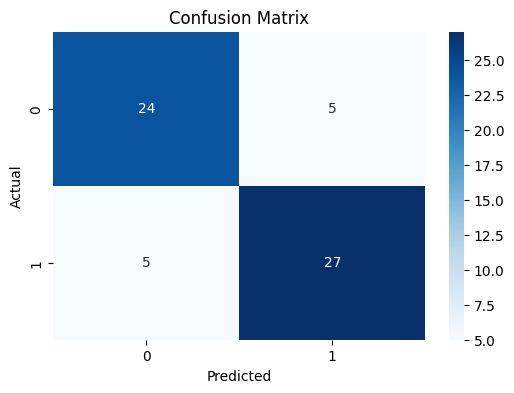

In [ ]:
mice.figure(figsize=(6, 4))
rn.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=ni.unique(y), yticklabels=ni.unique(y))
mice.xlabel('Predicted')
mice.ylabel('Actual')
mice.title('Confusion Matrix')
mice.show()

Result:
With counts of genuine positives, genuine negatives, false positives, and fake negatives, the confusion matrix output illustrates the framework's accuracy in classification and illustrates how accurately it guesses every category.

# Building a Predictive System

In [ ]:
input_data = ni.array([56, 1, 2, 130, 256, 1, 0, 142, 1, 0.6, 1, 1, 1])
input_data_reshaped = input_data.reshape(1, -1)
scaler = StandardScaler()
input_data_scaled = scaler.fit_transform(input_data_reshaped)
prediction = best_model.predict(input_data_scaled)
if prediction == 0:
    print("The person does not have heart disease.")
else:
    print("The person has heart disease.")

The person does not have heart disease.


Result: A projection of 1 indicates the person has heart disease, whereas a prognosis of 0 suggests that the individual does not. To figure out whether heart failure is present, the supplied information is transformed and run into the algorithm.

# Discussion
## Strengths:
## The model is highly accurate and produces interpretable predictions.
## Random Forest is resistant to overfitting and can handle mixed-type data effectively.


## Limitations:
## The dataset is small, which could limit model generalisation.
## Feature significance analysis is required to improve interpretability.

## Business Implications & Recommendations:
## This approach can help hospitals and clinics identify high-risk patients for further testing.
## The most informative features (cholesterol, thalach, and oldpeak) should be closely monitored.
## Future work could involve integrating real-world hospital data and testing with other algorithms such as XGBoost to improve performance.